<a href="https://colab.research.google.com/github/Maame-Pokuaa77/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


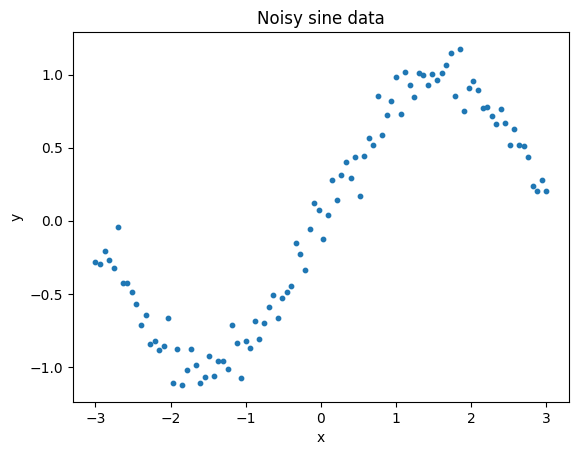

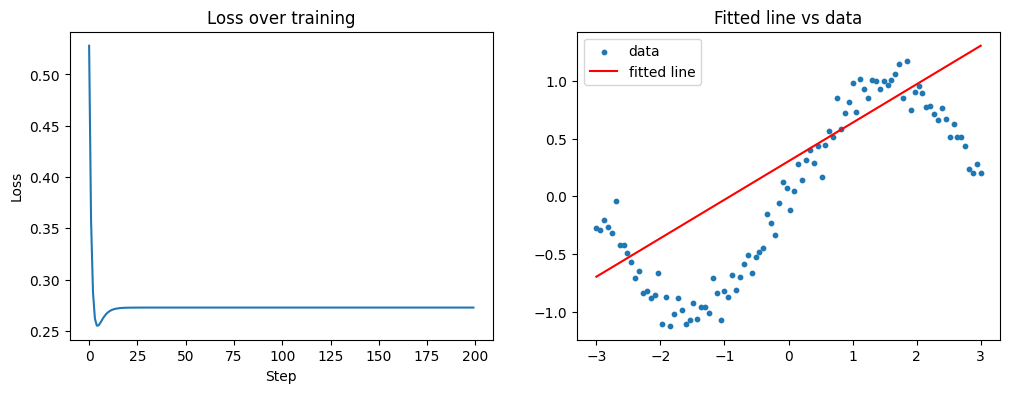

In [4]:
#Part 1.1h
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)
#   Plot it.
plt.scatter(x, y, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy sine data")
plt.show()

# TODO: Initialise w and b to small random values.
w= np.random.randn() * 0.1
b= np.random.randn() * 0.1
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.05
steps = 200
losses = []

for step in range(steps):

    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    losses.append(loss)
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    = w - lr * dw
    b    = w - lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over training")

axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, w * x + b, color ="red", label="fitted line")
axes[1].legend()
axes[1].set_title("Fitted line vs data")

plt.show()



The Single Neuron

1.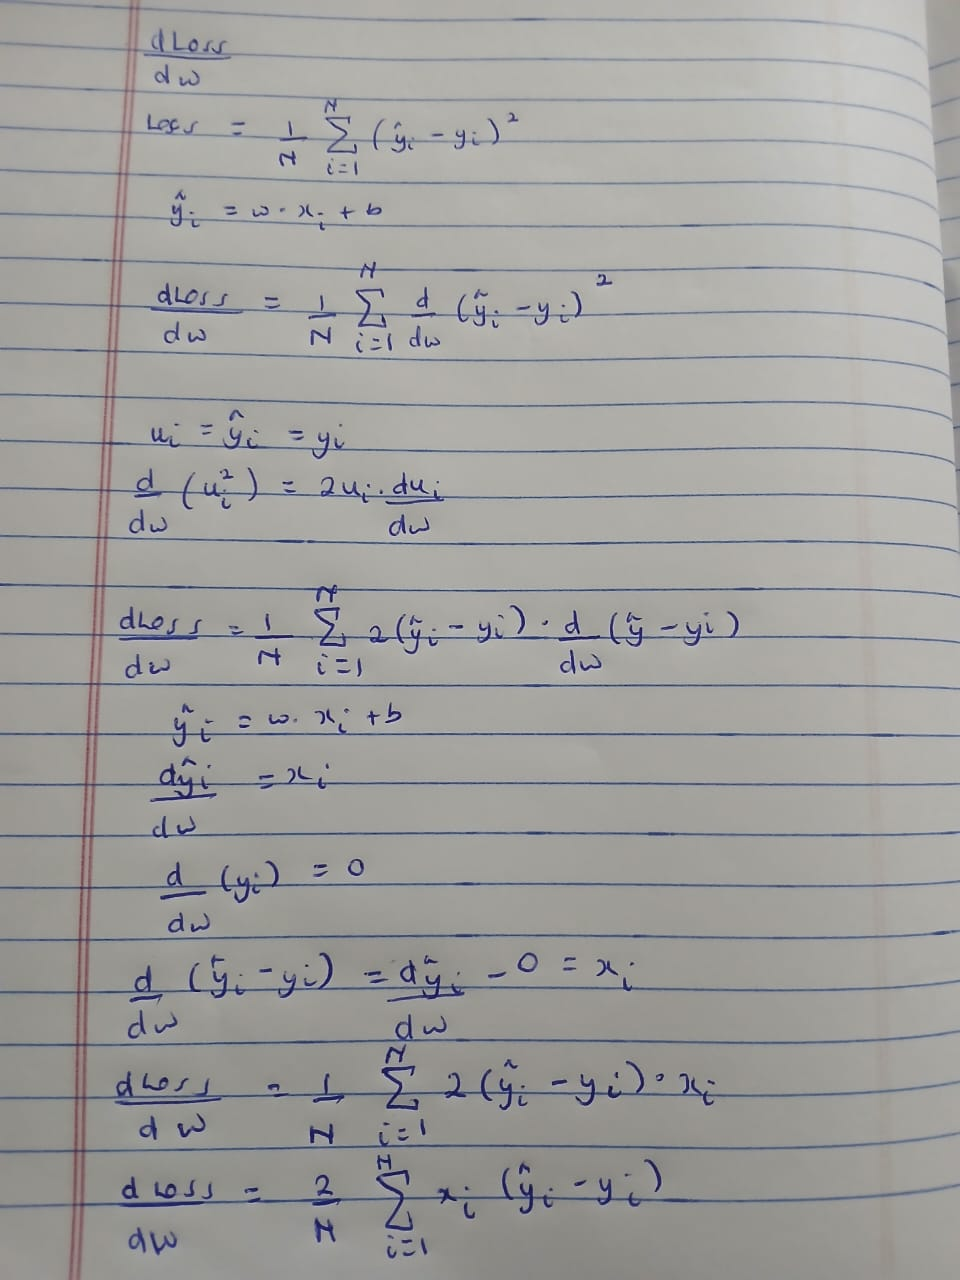


2.This is underfitting because from the image portraying the fitted line vs the data, the red line is failing to capture the training data's shape at all even though it's had 200 steps to try.A single neuron can't fit a sine wave because " y_hat = w·x + b"  describes a linear shape  no matter what values w and b take.